In [1]:
!pip install -q langgraph langchain-google-genai python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 565.1/565.1 kB 6.3 MB/s eta 0:00:00


MECHANISM 1


In [2]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

from langchain_google_genai import ChatGoogleGenerativeAI

from dotenv import load_dotenv
import os

In [3]:
load_dotenv()

True

In [4]:
class SubState(TypedDict):
  input_text:str
  translated_text:str

In [6]:
subgraph_llm=ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [7]:
def translate_text(state:SubState):
  prompt=f"""
  Translate the folloeing text to Urdu.
  Keep it natural and clear.Do not add extra content.ChatGoogleGenerativeAI

  Text:
  {state["input_text"]}
  """.strip()

  translated_text=subgraph_llm.invoke(prompt).content
  return {"translated_text":translated_text}

In [8]:
subgraph_builder=StateGraph(SubState)
subgraph_builder.add_node("translate_text",translate_text)

subgraph_builder.add_edge(START,"translate_text")
subgraph_builder.add_edge("translate_text",END)

subgraph=subgraph_builder.compile()

In [12]:
class ParentState(TypedDict):
  question:str
  answer_eng:str
  answer_urdu:str

In [10]:
parent_llm=ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [13]:
def generate_answer(state:ParentState):
  answer=parent_llm.invoke(
      f"You are a helpful assistant.Answer clearly. \n Question:{state['question']} "
  ).content
  return {'answer_eng':answer}

In [14]:
def translate_answer(state:ParentState):
  result=subgraph.invoke({'input_text':state['answer_eng']})
  return {'answer_urdu':result['translated_text']}

In [15]:
parent_builder=StateGraph(ParentState)
parent_builder.add_node("generate_answer",generate_answer)
parent_builder.add_node("translate_answer",translate_answer)

In [16]:
parent_builder.add_edge(START,"generate_answer")
parent_builder.add_edge("generate_answer","translate_answer")
parent_builder.add_edge("translate_answer",END)

In [19]:
graph=parent_builder.compile()

In [20]:
graph.invoke({'question':'What is quantum physics?'})

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (NOT_FOUND): 404 NOT_FOUND. {'error': {'code': 404, 'message': 'This model models/gemini-2.5-flash is no longer available to new users. Please update your code to use a newer model for the latest features and improvements. We recommend you to use the Interactions API (https://ai.google.dev/gemini-api/docs/migrate-to-interactions).', 'status': 'NOT_FOUND'}}

MECHANISM 2


In [21]:
def translate_text(state:ParentState):
  prompt=f"""
  Translate the folloeing text to Urdu.
  Keep it natural and clear.Do not add extra content.ChatGoogleGenerativeAI

  Text:
  {state['question']}
  """.strip()

  translated_text=subgraph_llm.invoke(prompt).content
  return {"translated_text":translated_text}

In [22]:
subgraph_builder=StateGraph(ParentState)
subgraph_builder.add_node("translate_text",translate_text)

subgraph_builder.add_edge(START,"translate_text")
subgraph_builder.add_edge("translate_text",END)

subhgraph=subgraph_builder.compile()

In [ ]:
def generate_answer(state:ParentState):
  answer=parent_llm.invoke(
      f"You are a helpful assistant.Answer clearly. \n Question:{state['question']} "
  ).content
  return {'answer_eng':answer}

In [23]:
parent_builder=StateGraph(ParentState)
parent_builder.add_node("generate_answer",generate_answer)
parent_builder.add_node("translate_answer",subgraph)


In [24]:
parent_builder.add_edge(START,"generate_answer")
parent_builder.add_edge("generate_answer","translate_answer")
parent_builder.add_edge("translate_answer",END)

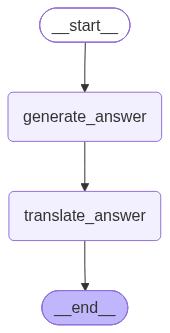

In [26]:
graph=parent_builder.compile()
graph